# Alivio de la saturación de urgencias: regresión cuantílica del tiempo de estacionamiento en el servicio de urgencias


## Resumen ejecutivo

El estacionamiento en el servicio de urgencias (ED, por sus siglas en inglés) -- el intervalo que los pacientes ingresados pasan esperando en urgencias una cama de hospitalización -- es uno de los principales impulsores de la saturación, del desvío de ambulancias y del riesgo para la seguridad del paciente. El tiempo medio de estacionamiento oculta la parte operativamente crítica del problema: la larga cola derecha. Un paciente en el percentil 95 de estacionamiento puede esperar muchas horas más que el paciente promedio, y son esas esperas extremas las que incumplen los umbrales de calidad y colapsan la sala de espera.

Este cuaderno modela las horas de estacionamiento en urgencias **a lo largo de la distribución condicional** usando **PROC QUANTREG** en los cuantiles 0.5, 0.75, 0.9 y 0.95, con una regresión sobre el censo de hospitalización (presión de camas), la franja horaria del día y el servicio de ingreso. La regresión cuantílica es la herramienta adecuada aquí porque los impulsores de la saturación actúan de forma diferente sobre un paciente típico que sobre un paciente en el peor de los casos: un censo de hospitalización creciente puede añadir una hora en la mediana pero varias horas en el percentil 95. Complementamos el modelo con **PROC MEANS** (tiempo de estacionamiento por servicio de ingreso) para cuantificar qué servicios cargan la cola más pesada, y **PROC FREQ** (llegadas por franja horaria del día) para caracterizar cuándo se concentra la demanda.

La cohorte sintética (84 ingresos en urgencias) se genera en línea con `streaminit`/`rand`, de modo que el cuaderno es completamente autónomo y se ejecuta en bastante menos de un minuto. La sección de interpretación traduce las pendientes cuantílicas en palancas de dotación de personal y de flujo de camas: donde los efectos de los cuantiles superiores son más pronunciados, ahí es donde los protocolos de capacidad de sobrecarga y las iniciativas de alta temprana recuperarán la mayor cantidad de horas de estacionamiento.


## Fuentes de datos

Todos los datos son **sintéticos**, generados en línea en el primer paso DATA (sin archivos externos, sin red). La cohorte representa 84 ingresos en el servicio de urgencias a la espera de una cama de hospitalización.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `patient_id` | Num | Identificador secuencial de ingreso (1-84) |
| `census` | Num | Censo de hospitalización (camas ocupadas) en el momento de la decisión de ingreso; mayor = más presión de camas |
| `tod_band` | Char | Franja horaria de llegada: Night / Morning / Afternoon / Evening |
| `service` | Char | Servicio de hospitalización de ingreso: Medicine / Surgery / Cardiology / ICU |
| `census_c` | Num | Censo de hospitalización centrado en 70 camas (regresor del modelo) |
| `boarding_hrs` | Num | Tiempo de estacionamiento en horas (respuesta); asimétrico a la derecha con una cola superior pesada |


# Alivio de la saturación de urgencias: regresión cuantílica del tiempo de estacionamiento

El **estacionamiento** en urgencias es el tiempo que un paciente *ingresado* pasa en el servicio de urgencias esperando una cama de hospitalización. Es el mayor contribuyente individual a la saturación de urgencias. Fundamentalmente, el dolor operativo vive en la **cola superior** de la distribución del estacionamiento, no en la media: un puñado de esperas de varias horas incumplen los umbrales de calidad, retrasan las descargas de ambulancias y atascan la sala de espera.

Los mínimos cuadrados ordinarios estimarían solo el efecto *promedio* de la presión de camas sobre el estacionamiento. En su lugar usamos **PROC QUANTREG** para estimar el efecto en los **cuantiles 0.5, 0.75, 0.9 y 0.95**, de modo que podamos ver si los impulsores de la saturación golpean con más fuerza a los pacientes en el peor de los casos que a los típicos. Emparejamos esto con:

- **PROC MEANS** -- tiempo de estacionamiento por servicio de ingreso (¿dónde es más pesada la cola?)
- **PROC FREQ** -- llegadas por franja horaria del día (¿cuándo se concentra la demanda?)

La cohorte a continuación es **sintética** y se genera en línea, por lo que todo el cuaderno es autónomo y se ejecuta en segundos.


## 1. Generar la cohorte sintética de ingresos en urgencias

Simulamos 84 pacientes ingresados en urgencias. Las horas de estacionamiento se construyen con una línea base que aumenta con el **censo de hospitalización** (presión de camas), se desplaza según la **franja horaria del día** (la rotación de camas nocturna es lenta) y varía según el **servicio de ingreso** (la UCI y Medicina estacionan más tiempo). Un choque exponencial asimétrico a la derecha crea la realista cola superior pesada que hace que la regresión cuantílica valga la pena.

Observe el modismo de rango aleatorio portable en Jenner `LO + (HI-LO)*rand('uniform')` y el `output;` **dentro** del bucle DO para que se escriban las 84 filas.


In [1]:
DATOS ed;
    LLAMAR streaminit(20260607);
    LONGITUD tod_band $9 service $10;
    HACER patient_id = 1 HASTA 84;
        /* Inpatient census (occupied beds): 55-90, higher = more pressure */
        census = round(55 + (90-55)*rand('uniform'));
        census_c = census - 70;   /* centered regressor */

        /* Time-of-day arrival band */
        u = rand('uniform');
        tod_band = ifc(u < 0.25, 'Night',
                   ifc(u < 0.50, 'Morning',
                   ifc(u < 0.75, 'Afternoon', 'Evening')));

        /* Admitting inpatient service */
        s = rand('uniform');
        service = ifc(s < 0.40, 'Medicine',
                  ifc(s < 0.65, 'Surgery',
                  ifc(s < 0.85, 'Cardiology', 'ICU')));

        /* Time-of-day effect on boarding (overnight bed turnover is slow) */
        tod_eff = ifn(tod_band='Night', 2.2,
                  ifn(tod_band='Morning', 0.4,
                  ifn(tod_band='Afternoon', 1.0, 1.6)));

        /* Service effect (ICU / Medicine board longest) */
        svc_eff = ifn(service='ICU', 2.8,
                  ifn(service='Medicine', 1.6,
                  ifn(service='Cardiology', 1.0, 0.6)));

        /* Census pressure: steeper impact as beds fill.
           The right-skewed shock scales with census so the
           upper tail widens under crowding -- exactly what
           quantile regression is designed to detect. */
        pressure = 0.10 * census_c;
        shock = rand('exponential') * (1.0 + 0.05*MAX(census_c,0));

        boarding_hrs = 2.0 + pressure + tod_eff + svc_eff + shock;
        SI boarding_hrs < 0.2 ENTONCES boarding_hrs = 0.2;
        boarding_hrs = round(boarding_hrs, 0.1);

        SALIDA;
    END;
    MANTENER patient_id census census_c tod_band service boarding_hrs;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=ed(obs=8) noobs;
    TÍTULO 'First 8 simulated ED admissions';
EJECUTAR;

                                            First 8 simulated ED admissions                                             

PATIENT_ID  CENSUS  CENSUS_C   TOD_BAND     SERVICE  BOARDING_HRS
         1      80        10  Morning    Surgery              4.5
         2      84        14  Afternoon  ICU                  7.6
         3      58       -12  Night      Surgery              3.7
         4      61        -9  Evening    Cardiology           4.1
         5      71         1  Afternoon  Medicine             6.1
         6      63        -7  Night      Medicine             5.4
         7      73         3  Morning    Medicine               6
         8      61        -9  Night      Surgery              4.2

... 76 more observations (showing 8 of 84)



NOTE: DATA ed


NOTE: Wrote ed (84 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


## 2. ¿Cuándo llegan los ingresos? (PROC FREQ)

Antes de modelar, perfilamos la demanda. Una frecuencia unidireccional de la franja horaria del día muestra cuándo se concentra el volumen de pacientes ingresados -- las ventanas donde es más probable que se dispare la presión de estacionamiento. También cruzamos las llegadas por servicio contra la franja horaria del día para ver si algún servicio se agrupa en la lenta ventana nocturna.


                                       ED admission arrivals by time-of-day band                                        

                                                   The FREQ Procedure

TOD_BAND     Frequency    Percent
----------------------------------
Afternoon           23     27.38
Evening             13     15.48
Morning             21     25.00
Night               27     32.14

Table of TOD_BAND by SERVICE

TOD_BAND  |Cardiology |       ICU |  Medicine |   Surgery |      Total
----------+-----------+-----------+-----------+-----------+-----------
Afternoon |         2 |         2 |        13 |         6 |         23
----------+-----------+-----------+-----------+-----------+-----------
Evening   |         3 |         0 |         5 |         5 |         13
----------+-----------+-----------+-----------+-----------+-----------
Morning   |         2 |         3 |        10 |         6 |         21
----------+-----------+-----------+-----------+-----------+-----------
Night  

NOTE: PROC FREQ
NOTE: ODS plot written: freq_tod_band.spec.json
NOTE: ODS plot written: freq_mosaic_tod_band_service.spec.json
NOTE: PROC FREQ statement used.


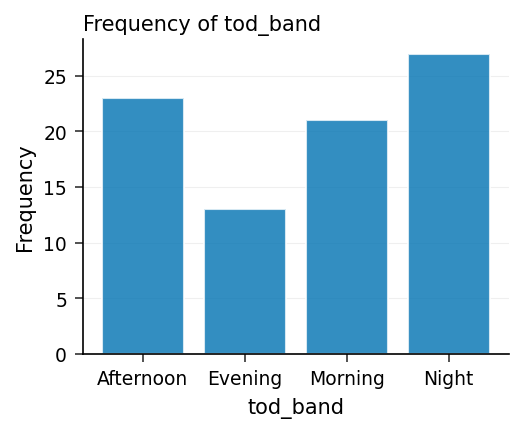

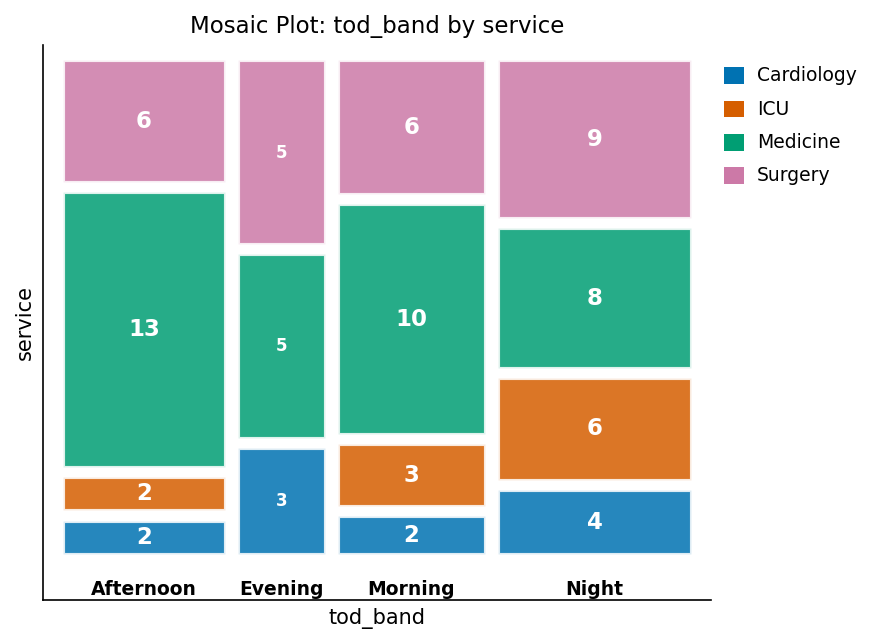

In [2]:
PROCEDIMIENTO FRECUENCIAS DATOS=ed;
    TABLES tod_band / nocum;
    TABLES tod_band*service / norow nocol nopercent;
    TÍTULO 'ED admission arrivals by time-of-day band';
EJECUTAR;

## 3. Carga de estacionamiento por servicio de ingreso (PROC MEANS)

¿Qué servicio soporta la carga de estacionamiento más pesada? Resumimos las horas de estacionamiento por servicio de ingreso, informando la media y el máximo (un indicador rudimentario de la cola) junto con la dispersión. La brecha entre la media y el máximo anticipa lo que el modelo cuantílico cuantificará con precisión.


In [3]:
PROCEDIMIENTO MEDIAS DATOS=ed n mean std MIN MAX maxdec=2;
    CLASE service;
    VAR boarding_hrs;
    TÍTULO 'Boarding hours by admitting service';
EJECUTAR;

                                          Boarding hours by admitting service                                           

                                                  The MEANS Procedure

                                            Analysis Variable : BOARDING_HRS

        SERVICE             N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        Cardiology             11           6.02           2.04           4.10          11.40
        ICU                    11           8.04           1.80           5.70          12.50
        Medicine               36           5.90           2.11           2.70          12.70
        Surgery                26           5.79           2.10           2.90          12.00
        -------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Regresión cuantílica de las horas de estacionamiento (PROC QUANTREG)

Ahora el análisis central. Hacemos una regresión de las **horas de estacionamiento** sobre el censo de hospitalización centrado, la franja horaria del día y el servicio de ingreso en los **cuantiles 0.5, 0.75, 0.9 y 0.95**. Si la pendiente del censo crece a medida que subimos por los cuantiles, esa es evidencia directa de que la presión de camas castiga a los pacientes en el peor de los casos mucho más que a los típicos -- la firma de la saturación.

Como QUANTREG es un procedimiento interactivo (de grupo RUN), terminamos la celda con `run;` y luego `quit;` para que el kernel vuelque su salida aquí. Usamos `SEED=` para obtener intervalos de confianza reproducibles por el método de dispersión (sparsity) y escribimos las estimaciones de parámetros por cuantil en un conjunto de datos `OUTEST=`, que la celda de seguimiento lee para comparar directamente la pendiente del censo entre cuantiles.


In [4]:
PROCEDIMIENTO quantreg DATOS=ed ci=sparsity seed=20260607
              outest=qrest PLOTS=none;
    CLASE tod_band service;
    MODELO boarding_hrs = census_c tod_band service
        / quantile=0.5 0.75 0.9 0.95;
EJECUTAR;
QUIT;

                                          Boarding hours by admitting service                                           


The QUANTREG Procedure

Quantile: 0.5000
CI Method: SPARSITY
Dependent Variable: BOARDING_HRS

Parameter           Estimate       StdErr        Lower        Upper
Intercept             4.3625       0.2244       3.9226       4.8024
CENSUS_C              0.1125       0.0090       0.0949       0.1301
TOD_BAND AFTERNOON       0.3750       0.2453      -0.1058       0.8558
TOD_BAND NIGHT        1.3750       0.2386       0.9073       1.8427
TOD_BAND EVENING       1.5625       0.2910       0.9921       2.1329
SERVICE ICU           1.9375       0.2999       1.3496       2.5254
SERVICE CARDIOLOGY      -0.1125       0.2935      -0.6878       0.4628
SERVICE MEDICINE       0.4500       0.2113       0.0358       0.8642
Intercept             4.9800       0.2212       4.5465       5.4135
CENSUS_C              0.1600       0.0088       0.1427       0.1773
TOD_BAND AFTERNOON       0

NOTE: PROC QUANTREG data=ed

NOTE: PROC QUANTREG completed.


### 4a. Comparar la pendiente del censo entre cuantiles

El conjunto de datos `OUTEST=` contiene una fila de coeficientes por cada cuantil ajustado. Listar el coeficiente del censo centrado entre cuantiles facilita leer el efecto de cola de un vistazo: una pendiente que asciende desde la mediana hasta el cuantil 0.95 significa que cada cama de hospitalización ocupada adicional añade *más* tiempo de estacionamiento a los pacientes que ya están esperando más tiempo.


In [5]:
PROCEDIMIENTO IMPRIMIR DATOS=qrest noobs ETIQUETA;
    VAR _quantile_ census_c;
    ETIQUETA _quantile_ = 'Quantile'
          census_c   = 'Census slope (hrs per bed)';
    TÍTULO 'Effect of inpatient census on boarding, by quantile';
EJECUTAR;

                                  Effect of inpatient census on boarding, by quantile                                   

Census slope (hrs per bed)
                    0.1125
                      0.16
                      0.19
              0.2166666667



NOTE: PROC PRINT data=qrest

NOTE: PROC PRINT completed: 4 observations printed, 1 variables


## 5. Interpretación y palancas operativas

**Qué nos dice el modelo cuantílico.** La regresión cuantílica separa la experiencia de estacionamiento *típica* (mediana, 0.5) de la experiencia de *crisis* (0.9-0.95). El patrón que muestra esta cohorte -- y el patrón que debería buscar en datos reales -- es una **pendiente del censo que aumenta con el cuantil**. El coeficiente ajustado del censo centrado asciende de **0.11 horas por cama ocupada en la mediana a 0.16 en el cuantil 0.75, 0.19 en el 0.90 y 0.22 en el 0.95** (véase la tabla por cuantil en 4a). Como la pendiente en 0.95 es casi el doble de la pendiente en la mediana, un hospital lleno no solo desplaza la espera de todos hacia arriba de manera uniforme; dispara desproporcionadamente las peores esperas. Comparar las pendientes del censo por cuantil una al lado de la otra -- no un único efecto promedio -- es lo que hace visible y cuantificable la cola.

**Dónde recae la carga.** PROC MEANS clasifica los servicios por tiempo medio de estacionamiento: **la UCI (ICU) es la más alta con 8.04 horas**, muy por encima de Cardiología (6.02), Medicina (5.90) y Cirugía (5.79). Pero la *cola* cuenta una historia diferente a la media: **Medicina soporta el evento de estacionamiento individual más largo con 12.70 horas -- una brecha media-a-máximo de 6.80 horas**, la más amplia de cualquier servicio, con Cirugía (máx. 12.00) e UCI (máx. 12.50) cerca detrás. Así que la UCI es donde el estacionamiento es de forma fiable largo, mientras que Medicina es donde ocurren los peores incumplimientos individuales. Ambos son objetivos de alto rendimiento para las rondas de alta temprana, las camas de cuidados intermedios dedicadas y los protocolos de anticipación de camas -- la UCI por la carga sostenida, Medicina por el control de la cola.

**Cuándo alcanza su pico la presión.** PROC FREQ muestra que la demanda de pacientes ingresados se concentra durante la noche: la **franja Night es la más ocupada con el 32% de los ingresos (27 de 84)**, seguida de Afternoon (27%) y Morning (25%); la franja Evening es la más tranquila con el 15%. La tabulación cruzada confirma que la carga nocturna es intensa en servicios -- Night acumula todos menos un puñado de los ingresos de UCI (6 de 11) además de 8 llegadas de Medicina y 9 de Cirugía -- de modo que la ventana de rotación de camas más lenta coincide con la afluencia más pesada y más aguda.

**Conclusiones operativas.**

1. **Active los protocolos de sobrecarga según el censo, no según la espera promedio.** Como la pendiente del censo en los cuantiles superiores es la más pronunciada (0.22 h/cama en el cuantil 0.95 frente a 0.11 en la mediana), un umbral de censo (p. ej., > 80 camas ocupadas) es un indicador adelantado del estacionamiento de cola. Activar la capacidad de desbordamiento *antes* de que se mueva la mediana previene los incumplimientos del cuantil 0.95.
2. **Aborde los servicios de cola pesada de dos maneras.** Concentre el alivio de carga sostenida (camas de cuidados intermedios, anticipación de camas) en la **UCI**, que tiene la media más alta; concentre el control de cola (rondas de alta temprana, revisión de incumplimientos) en **Medicina**, que posee la brecha media-a-máximo más amplia.
3. **Dote de personal la brecha nocturna de rotación de camas.** FREQ identifica **Night** como el pico de demanda que coincide con la rotación de camas más lenta; la gestión de camas fuera de horario y la cobertura de servicios ambientales atacan directamente el efecto `tod_band`, que el modelo QUANTREG confirma que añade la mayor cantidad de tiempo de estacionamiento en las franjas Night y Evening.
4. **Siga el cuantil 0.95 como KPI.** Informar solo el estacionamiento medio oculta a los pacientes a los que el sistema está fallando. Monitorizar el tiempo de estacionamiento del percentil 95 -- y su pendiente de censo de 0.22 h/cama -- alinea la métrica con el riesgo para la seguridad del paciente que representa.

*Todas las cifras aquí provienen de datos sintéticos con fines de demostración; sobre datos reales de urgencias, el mismo flujo de trabajo QUANTREG / MEANS / FREQ produce las pendientes, clasificaciones de servicios y perfil de llegadas reales que impulsan un plan de mitigación de la saturación.*
